In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import shap
from utils import corr

f:\Study\CS\miniconda\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -------------------------------
# Extract Data
# -------------------------------
# metrics = pd.read_csv('mt_exp_dataset/metrics.csv')
metrics = pd.read_csv('metrics_collection.csv')
metrics

,id,conversation,question_id,model_name,time,mt,exp,nll,N100,N150,...,N400,word_speed,line_speed,pixel_speed,saccade,fft,rrt,tft,skip_rate,fixation_time
0,1,1,100,vicuna-13b-v1.2,28163,2.0,1.75,152.017463,62,17,...,0,331.329412,4693.833333,2.936585,143,282.2,232.4,282.2,0.327273,15850.000000
1,1,2,100,claude-v1,17616,1.0,1.25,176.372082,42,25,...,0,320.290909,3523.200000,1.288177,79,348.6,448.2,448.2,0.435294,25783.333333
2,2,1,88,gpt-3.5-turbo,28752,2.0,2.00,152.409554,77,34,...,4,315.956044,4107.428571,1.821815,141,116.2,232.4,348.6,0.494505,26450.000000
3,2,2,88,vicuna-13b-v1.2,23949,1.0,1.00,126.195426,66,26,...,2,342.128571,3991.500000,1.962668,130,348.6,116.2,199.2,0.428571,21616.666667
4,3,1,100,gpt-3.5-turbo,22202,2.0,2.00,127.155161,58,26,...,1,267.493976,3171.714286,2.315026,105,265.6,1228.4,282.2,0.272727,23050.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,568,2,100,claude-v1,20279,1.0,1.00,176.372082,42,19,...,3,368.709091,4055.800000,1.696901,113,199.2,-1.0,199.2,0.646154,6533.333333
978,569,1,98,alpaca-13b,11810,1.0,1.25,91.159246,35,21,...,3,281.190476,3936.666667,1.833451,62,332.0,182.6,780.2,0.333333,10516.666667
979,569,2,98,gpt-3.5-turbo,7814,2.0,1.75,136.538309,19,11,...,1,108.527778,1302.333333,0.595571,48,182.6,166.0,182.6,0.666667,6416.666667
980,570,1,100,gpt-4,11398,1.0,1.00,136.637391,32,21,...,1,175.353846,1899.666667,0.919226,71,1693.2,1311.4,1693.2,0.658537,11683.333333


Baseline:
Random Selection: MSE = 0.2997
R squared: -0.40431709756537404

Model Evaluation (Mean Squared Error):
Polynomial Regression (degree 2): MSE = 0.3969
Polynomial Regression (degree 2): R^2 = -0.8603
Polynomial Regression (degree 2): Adjusted R^2 = -1.0600

Ridge Regression: MSE = 0.1630
Ridge Regression: R^2 = 0.2361
Ridge Regression: Adjusted R^2 = 0.1541

Lasso Regression: MSE = 0.1799
Lasso Regression: R^2 = 0.1568
Lasso Regression: Adjusted R^2 = 0.0663

ElasticNet Regression: MSE = 0.1799
ElasticNet Regression: R^2 = 0.1568
ElasticNet Regression: Adjusted R^2 = 0.0663

Decision Tree Regression: MSE = 0.1561
Decision Tree Regression: R^2 = 0.2685
Decision Tree Regression: Adjusted R^2 = 0.1900

Random Forest Regression: MSE = 0.1285
Random Forest Regression: R^2 = 0.3980
Random Forest Regression: Adjusted R^2 = 0.3333



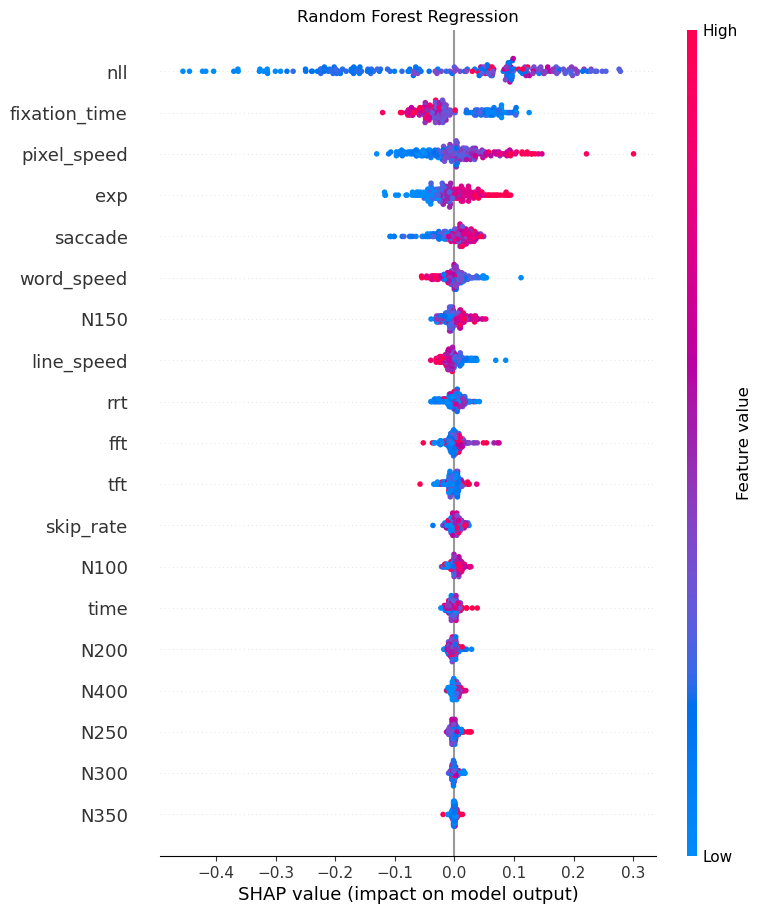

Gradient Boosting Regression: MSE = 0.1124
Gradient Boosting Regression: R^2 = 0.4732
Gradient Boosting Regression: Adjusted R^2 = 0.4166

Support Vector Regression: MSE = 0.2217
Support Vector Regression: R^2 = -0.0389
Support Vector Regression: Adjusted R^2 = -0.1504



In [3]:
# Put data into a DataFrame
df = pd.DataFrame({'mt': metrics['mt'], 'model_name': metrics['model_name'], 'exp': metrics['exp'], 'time': metrics['time'],
                   'nll': metrics['nll'], 'saccade': metrics['saccade'], 'N100': metrics['N100'], 'N150': metrics['N150'],
                   'N200': metrics['N200'], 'N250': metrics['N250'], 'N300': metrics['N300'], 'N350': metrics['N350'],
                   'N400': metrics['N400'], 'word_speed': metrics['word_speed'], 'line_speed': metrics['line_speed'],
                   'pixel_speed': metrics['pixel_speed'], 'fft': metrics['fft'], 'rrt': metrics['rrt'],
                   'tft': metrics['tft'], 'skip_rate': metrics['skip_rate'], 'fixation_time': metrics['fixation_time']})

# generate a new column 'model', which is a numerical representation of 'model_name'
df['model'] = pd.factorize(df['model_name'])[0]

# -------------------------------
# Define Features and Target
# -------------------------------
# Assume 'a' is the target and the others are features.
X = df[['exp', 'time', 'nll', 'saccade', 'N100', 'N150', 'N200', 'N250', 'N300', 'N350', 'N400',
         'word_speed', 'line_speed', 'pixel_speed', 'fft', 'rrt', 'tft', 'skip_rate', 'fixation_time']]
X_cols = X.columns.tolist()
y = df['mt']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# give the mse of random selection, assume the data is uniformly distributed
y_pred = np.random.uniform(y_test.min(), y_test.max(), y_test.shape[0])
mse = mean_squared_error(y_test, y_pred)
print("Baseline:")
print(f"Random Selection: MSE = {mse:.4f}")
print(f"R squared: {1 - mse/np.var(y_test)}\n")

# -------------------------------
# Define Different Regression Models
# -------------------------------
models = {
    # Polynomial Regression: This uses PolynomialFeatures to include non-linear combinations.
    'Polynomial Regression (degree 2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),

    # Regularized linear models:
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'ElasticNet Regression': ElasticNet(alpha=0.1, l1_ratio=0.5),

    # Tree-based methods:
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(n_estimators=90, random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),

    # Support Vector Regression:
    # We include StandardScaler in the pipeline because SVR is sensitive to the scale of features.
    'Support Vector Regression': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1))
}

# -------------------------------
# Train and Evaluate Each Model
# -------------------------------
print("Model Evaluation (Mean Squared Error):")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name}: MSE = {mse:.4f}")

    # Caluculate the R^2
    r2 = model.score(X_test, y_test)
    print(f"{name}: R^2 = {r2:.4f}")

    # Calculate the adjusted R^2
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"{name}: Adjusted R^2 = {adj_r2:.4f}\n")

    # Calculate the SHAP values
    if isinstance(model, RandomForestRegressor):
        shap_values = shap.TreeExplainer(model).shap_values(X_test)
        shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
        plt.title(name)
        plt.show()


In [4]:
# corr(metrics, 'mt', 'model_name')
corr(metrics, 'mt', 'exp')
print()
corr(metrics, 'mt', 'time')
print()
corr(metrics, 'mt', 'nll')
print()
corr(metrics, 'mt', 'saccade')
print()
corr(metrics, 'mt', 'N100')
print()
corr(metrics, 'mt', 'N150')
print()
corr(metrics, 'mt', 'N200')
print()
corr(metrics, 'mt', 'N250')
print()
corr(metrics, 'mt', 'N300')
print()
corr(metrics, 'mt', 'N350')
print()
corr(metrics, 'mt', 'N400')
print()
corr(metrics, 'mt', 'word_speed')
print()
corr(metrics, 'mt', 'line_speed')
print()
corr(metrics, 'mt', 'pixel_speed')
print()
corr(metrics, 'mt', 'fft')
print()
corr(metrics, 'mt', 'rrt')
print()
corr(metrics, 'mt', 'tft')
print()
corr(metrics, 'mt', 'skip_rate')
print()
corr(metrics, 'mt', 'fixation_time')
print()

mt vs exp pearson & spearman
0.23567134659639338, p-value: 7.352185523579036e-14
0.2332968290253181, p-value: 1.322589935140272e-13

mt vs time pearson & spearman
0.16754599600912645, p-value: 1.2844231013968232e-07
0.16922164210904175, p-value: 9.573324822920765e-08

mt vs nll pearson & spearman
0.24976759915510593, p-value: 1.9704146424177663e-15
0.2515477679724644, p-value: 1.2272192535632642e-15

mt vs saccade pearson & spearman
0.15533430527321868, p-value: 1.002178809363328e-06
0.1654309679466378, p-value: 1.853613339315883e-07

mt vs N100 pearson & spearman
0.18063308695974442, p-value: 1.1965344704407563e-08
0.19579270808420238, p-value: 6.104796986983629e-10

mt vs N150 pearson & spearman
0.1450489758139506, p-value: 5.0248288149439634e-06
0.1539662212226642, p-value: 1.249588662459372e-06

mt vs N200 pearson & spearman
0.11024841973701618, p-value: 0.0005381799935655882
0.1090415138855624, p-value: 0.0006196152305295177

mt vs N250 pearson & spearman
0.09582636127843258, p-va

In [5]:
# Model 1: Linear regression of exp_score on nll
model1 = smf.ols('mt ~ nll', data=metrics).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     mt   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     65.20
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.97e-15
Time:                        13:00:42   Log-Likelihood:                -612.53
No. Observations:                 982   AIC:                             1229.
Df Residuals:                     980   BIC:                             1239.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1260      0.049     23.208      0.000       1.031       1.221
nll            0.0025      0.000      8.075      0.000       0.002       0.003
==============================================================================
Omnibus:                     5355.663   Durbin-Watson:                   3.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.188
Skew:                           0.015   Prob(JB):                     5.30e-24
Kurtosis:                       1.382   Cond. No.                         535.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
model1 = smf.ols('exp ~ saccade', data=metrics).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    exp   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.424
Date:                Wed, 07 May 2025   Prob (F-statistic):              0.233
Time:                        13:00:42   Log-Likelihood:                -380.60
No. Observations:                 982   AIC:                             765.2
Df Residuals:                     980   BIC:                             775.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4674      0.030     49.619      0.000       1.409       1.525
saccade        0.0003      0.000      1.193      0.233      -0.000       0.001
==============================================================================
Omnibus:                       16.103   Durbin-Watson:                   3.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.581
Skew:                           0.010   Prob(JB):                     6.22e-07
Kurtosis:                       3.836   Cond. No.                         307.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
# Model 2: Linear regression of exp_score on model_name
model2 = smf.ols('mt ~ model_name', data=metrics).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     mt   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     21.61
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.46e-20
Time:                        13:00:43   Log-Likelihood:                -592.59
No. Observations:                 982   AIC:                             1197.
Df Residuals:                     976   BIC:                             1227.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         1.3296      0.033     40.085      0.000       1.265       1.395
model_name[T.claude-v1]           0.2589      0.045      5.729      0.000       0.170       0.348
model_name[T.gpt-3.5-turbo]       0.3020      0.042      7.135      0.000       0.219       0.385
model_name[T.gpt-4]               0.0412      0.058      0.715      0.475      -0.072       0.154
model_name[T.llama-13b]          -0.1654      0.064     -2.603      0.009      -0.290      -0.041
model_name[T.vicuna-13b-v1.2]     0.2259      0.049      4.624      0.000       0.130       0.322
==============================================================================
Omnibus:                     7104.691   Durbin-Watson:                   2.916
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               93.188
Skew:                          -0.087   Prob(JB):                     5.82e-21
Kurtosis:                       1.501   Cond. No.                         6.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
# Model 3: Linear regression of exp_score on multiple predictors
model3 = smf.ols('exp ~ nll + np.log(time) + word_speed + line_speed + pixel_speed + saccade', data=metrics).fit()
model3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    exp   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     9.507
Date:                Wed, 07 May 2025   Prob (F-statistic):           3.60e-10
Time:                        13:00:43   Log-Likelihood:                -353.39
No. Observations:                 982   AIC:                             720.8
Df Residuals:                     975   BIC:                             755.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0699      0.454      0.154      0.878      -0.822       0.962
nll             -0.0007      0.000     -2.493      0.013      -0.001      -0.000
np.log(time)     0.1785      0.053      3.398      0.001       0.075       0.282
word_speed      -0.0012      0.000     -4.171      0.000      -0.002      -0.001
line_speed    1.814e-05   2.42e-05      0.751      0.453   -2.93e-05    6.56e-05
pixel_speed      0.0615      0.016      3.878      0.000       0.030       0.093
saccade         -0.0002      0.000     -0.368      0.713      -0.001       0.001
==============================================================================
Omnibus:                       19.582   Durbin-Watson:                   3.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.562
Skew:                           0.029   Prob(JB):                     6.97e-09
Kurtosis:                       3.956   Cond. No.                     1.69e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.69e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
# Model 4: Linear regression of mt on multiple predictors
model4 = smf.ols('mt ~ nll + model_name + line_speed + pixel_speed + saccade + fixation_time', data=metrics).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     mt   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     26.70
Date:                Wed, 07 May 2025   Prob (F-statistic):           3.13e-45
Time:                        13:00:43   Log-Likelihood:                -524.86
No. Observations:                 982   AIC:                             1072.
Df Residuals:                     971   BIC:                             1126.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.8863      0.089      9.926      0.000       0.711       1.061
model_name[T.claude-v1]          -0.0686      0.055     -1.250      0.212      -0.176       0.039
model_name[T.gpt-3.5-turbo]       0.2979      0.043      6.884      0.000       0.213       0.383
model_name[T.gpt-4]               0.0530      0.055      0.968      0.333      -0.054       0.160
model_name[T.llama-13b]          -0.2385      0.062     -3.878      0.000      -0.359      -0.118
model_name[T.vicuna-13b-v1.2]     0.1972      0.046      4.262      0.000       0.106       0.288
nll                               0.0035      0.001      6.464      0.000       0.002       0.005
line_speed                    -3.081e-05   1.77e-05     -1.737      0.083   -6.56e-05       4e-06
pixel_speed                       0.0620      0.024      2.635      0.009       0.016       0.108
saccade                           0.0004      0.000      0.917      0.359      -0.000       0.001
fixation_time                 -2.939e-06   2.06e-06     -1.427      0.154   -6.98e-06     1.1e-06
==============================================================================
Omnibus:                      243.844   Durbin-Watson:                   2.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               43.443
Skew:                          -0.028   Prob(JB):                     3.69e-10
Kurtosis:                       1.971   Cond. No.                     1.56e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.56e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [10]:
# Suppose df is your DataFrame, and X_cols are your predictors:
# Add constant for intercept
X_with_const = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame({
    'variable': X_with_const.columns,
    'VIF': [variance_inflation_factor(X_with_const.values, i)
            for i in range(X_with_const.shape[1])]
})

print(vif_data)

         variable        VIF
0           const  99.134072
1             exp   1.077543
2            time  10.988353
3             nll   1.565761
4         saccade   5.208536
5            N100   9.369235
6            N150  13.993958
7            N200  13.195463
8            N250  13.306725
9            N300  12.974635
10           N350  12.823937
11           N400   5.823452
12     word_speed  12.793686
13     line_speed  11.732548
14    pixel_speed   5.469572
15            fft   1.190453
16            rrt   1.209066
17            tft   1.387436
18      skip_rate   2.056960
19  fixation_time   3.398470


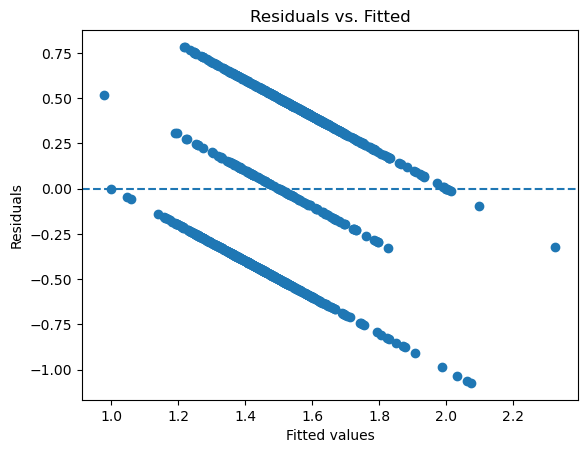

In [11]:
# Correctly select the columns for the independent variables
model = sm.OLS(df['mt'], sm.add_constant(df[['exp', 'time', 'nll', 'saccade']])).fit()

# Get fitted values and residuals
fitted = model.fittedvalues
resid = model.resid

# Plot
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

In [12]:
robust_results = model.get_robustcov_results(cov_type='HC3')

print(robust_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     mt   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     35.45
Date:                Wed, 07 May 2025   Prob (F-statistic):           1.11e-27
Time:                        13:00:43   Log-Likelihood:                -580.44
No. Observations:                 982   AIC:                             1171.
Df Residuals:                     977   BIC:                             1195.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6331      0.074      8.581      0.0